<a href="https://colab.research.google.com/github/nanditanair05-byte/intermediate_assesment_2/blob/main/Intermediate_Assessment2__nandita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("/content/drive/MyDrive/DSA/data science problem/train_LZdllcl.csv")
test = pd.read_csv("/content/drive/MyDrive/DSA/data science problem/test_2umaH9m.csv")
sample_submission = pd.read_csv("/content/drive/MyDrive/DSA/data science problem/sample_submission_M0L0uXE.csv")



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Submission shape:", sample_submission.shape)

Train shape: (54808, 14)
Test shape: (23490, 13)
Submission shape: (23490, 2)


In [ ]:
train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [ ]:
train.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


In [ ]:
train.duplicated().sum()

np.int64(0)

In [ ]:
train.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [ ]:
train['education'].value_counts(dropna=False)

,count
education,
Bachelor's,36669
Master's & above,14925
NaN,2409
Below Secondary,805


In [ ]:
train['previous_year_rating'].value_counts(dropna=False)

,count
previous_year_rating,
3.0,18618
5.0,11741
4.0,9877
1.0,6223
2.0,4225
NaN,4124


In [ ]:
missing_percent = (train.isnull().sum() / len(train)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': train.isnull().sum(),
    'Missing Percentage': missing_percent
})

missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

missing_summary

,Missing Count,Missing Percentage
education,2409,4.395344
previous_year_rating,4124,7.524449


In [ ]:
pd.crosstab(
    train['education'].isna(),
    train['is_promoted'],
    normalize='index'
) * 100

is_promoted,0,1
education,,
False,91.324262,8.675738
True,94.935658,5.064342


In [ ]:
pd.crosstab(
    train['previous_year_rating'].isna(),
    train['is_promoted'],
    normalize='index'
) * 100

is_promoted,0,1
previous_year_rating,,
False,91.458843,8.541157
True,91.779825,8.220175


Class Balance

In [ ]:
train['is_promoted'].value_counts()

,count
is_promoted,
0,50140
1,4668


In [ ]:
train['is_promoted'].value_counts(normalize=True) * 100

,proportion
is_promoted,
0,91.482995
1,8.517005


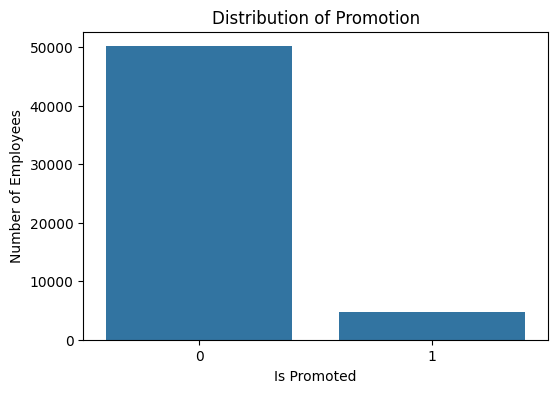

In [ ]:

plt.figure(figsize=(6,4))

sns.countplot(data=train, x='is_promoted')

plt.title('Distribution of Promotion')
plt.xlabel('Is Promoted')
plt.ylabel('Number of Employees')

plt.show()

Numerical Distributions


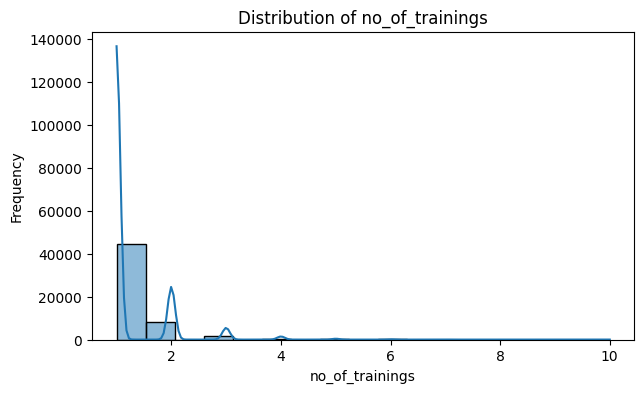

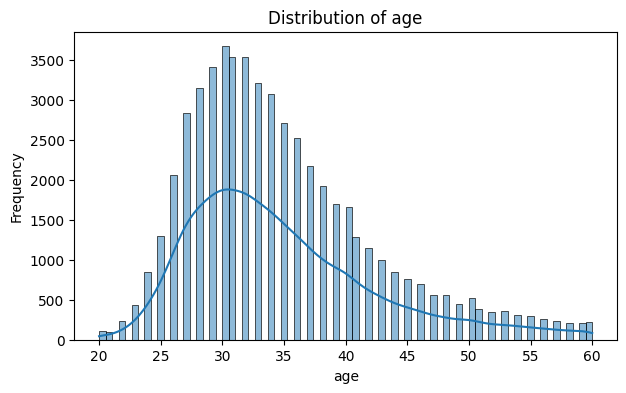

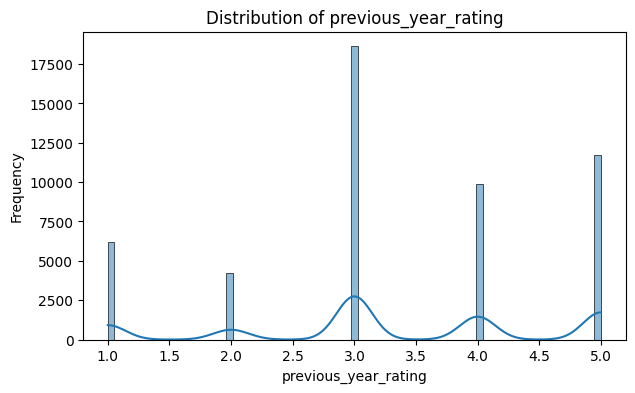

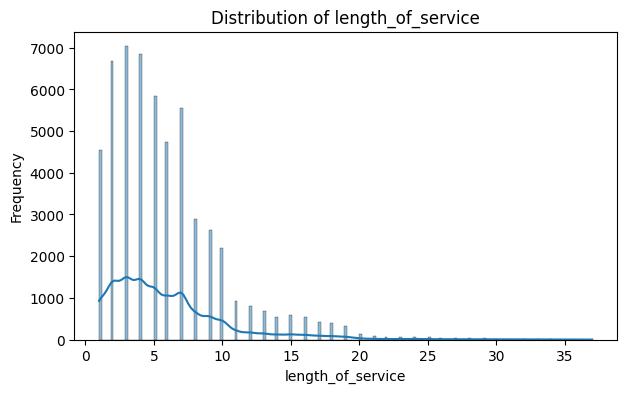

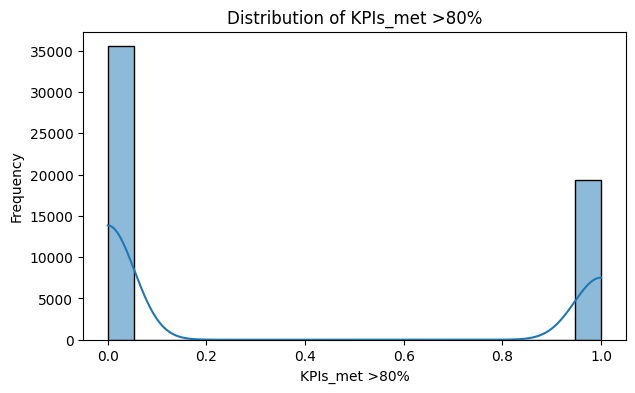

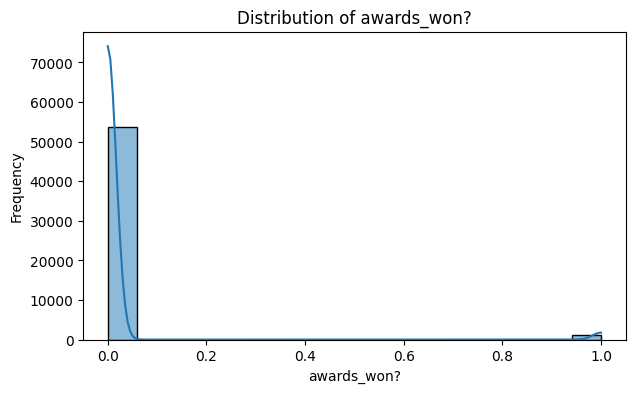

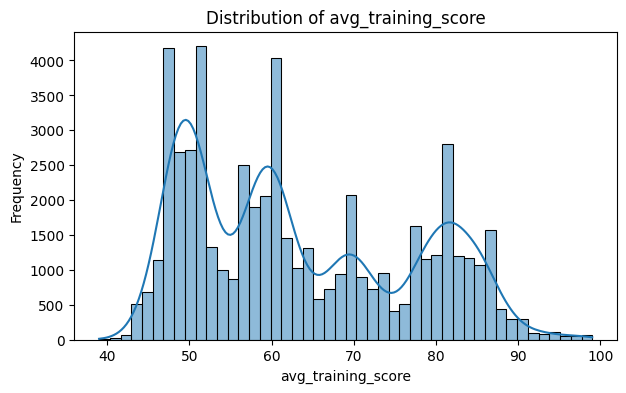

In [ ]:
numeric_features = [
    'no_of_trainings',
    'age',
    'previous_year_rating',
    'length_of_service',
    'KPIs_met >80%',
    'awards_won?',
    'avg_training_score'
]
for col in numeric_features:
    plt.figure(figsize=(7, 4))

    sns.histplot(data=train, x=col, kde=True)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.show()

Check Skewness

In [ ]:
skewness = train[numeric_features].skew().sort_values(ascending=False)

skewness

,0
awards_won?,6.338914
no_of_trainings,3.445434
length_of_service,1.738061
age,1.007432
KPIs_met >80%,0.619909
avg_training_score,0.451908
previous_year_rating,-0.310638


Outlier analysis

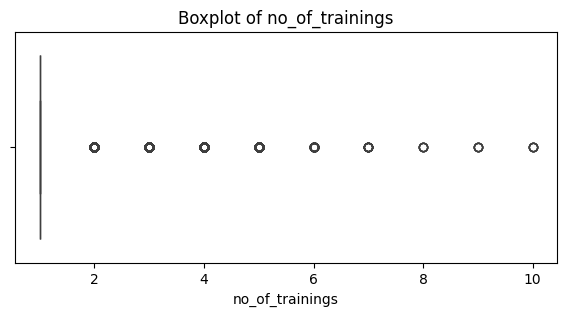

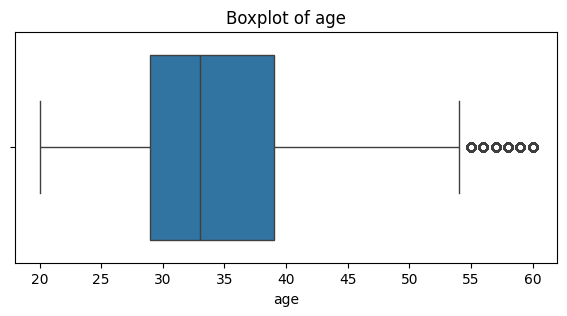

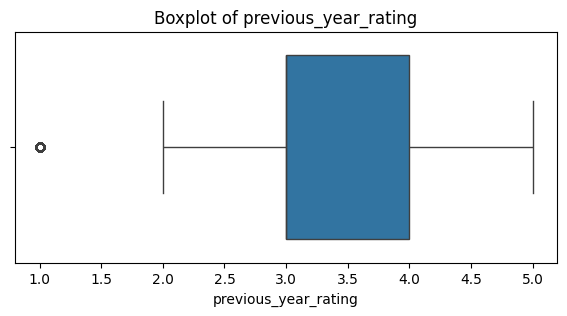

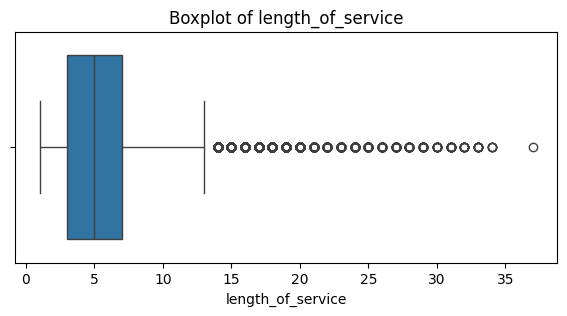

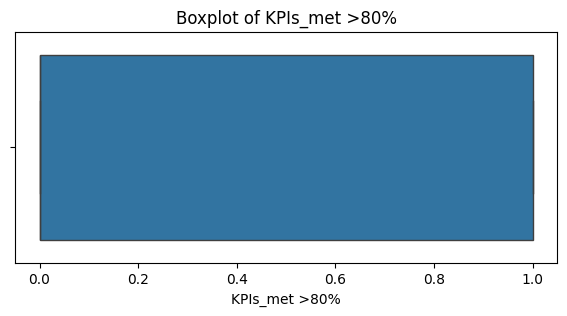

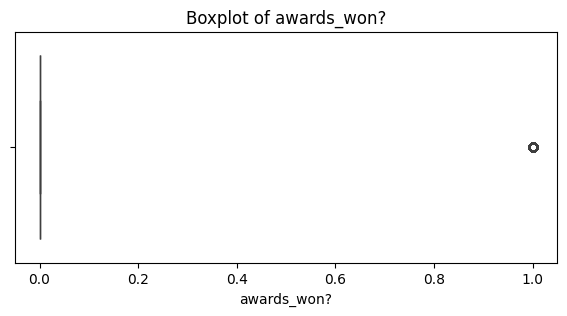

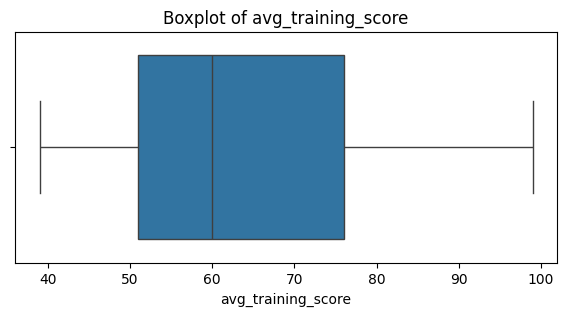

In [ ]:
for col in numeric_features:
    plt.figure(figsize=(7, 3))

    sns.boxplot(x=train[col])

    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

    plt.show()

Analyze categorical features

In [ ]:
categorical_cols = train.select_dtypes(include='object').columns.tolist()

print(categorical_cols)

['department', 'region', 'education', 'gender', 'recruitment_channel']


In [ ]:
for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(train[col].value_counts(dropna=False))


===== department =====
department
Sales & Marketing    16840
Operations           11348
Technology            7138
Procurement           7138
Analytics             5352
Finance               2536
HR                    2418
Legal                 1039
R&D                    999
Name: count, dtype: int64

===== region =====
region
region_2     12343
region_22     6428
region_7      4843
region_15     2808
region_13     2648
region_26     2260
region_31     1935
region_4      1703
region_27     1659
region_16     1465
region_28     1318
region_11     1315
region_23     1175
region_29      994
region_32      945
region_19      874
region_20      850
region_14      827
region_25      819
region_17      796
region_5       766
region_6       690
region_30      657
region_8       655
region_10      648
region_1       610
region_24      508
region_12      500
region_9       420
region_21      411
region_3       346
region_34      292
region_33      269
region_18       31
Name: count, dtype: int

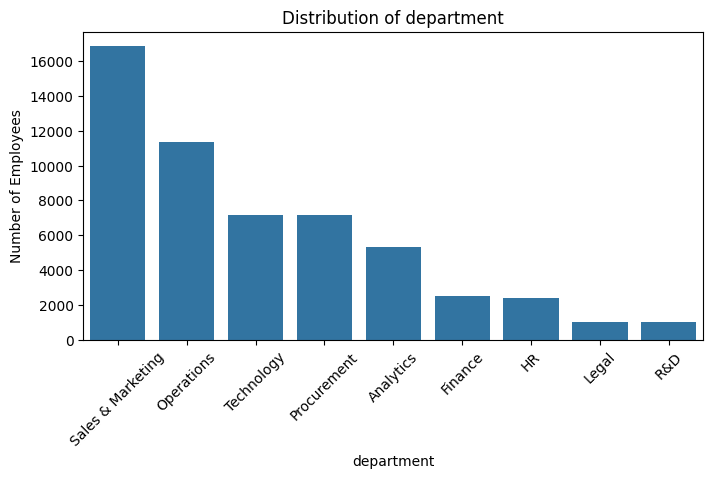

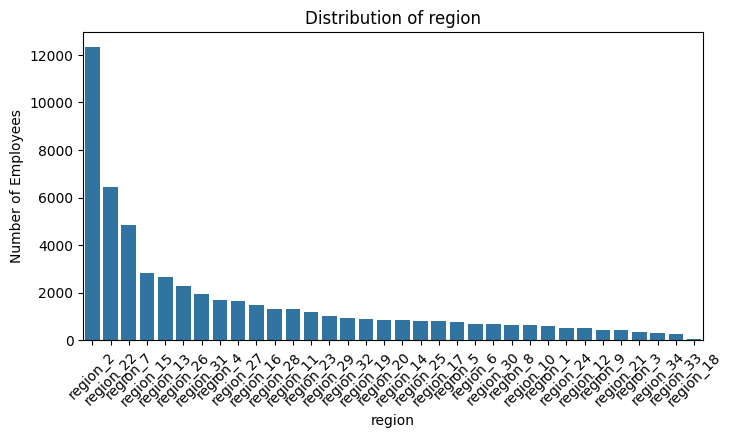

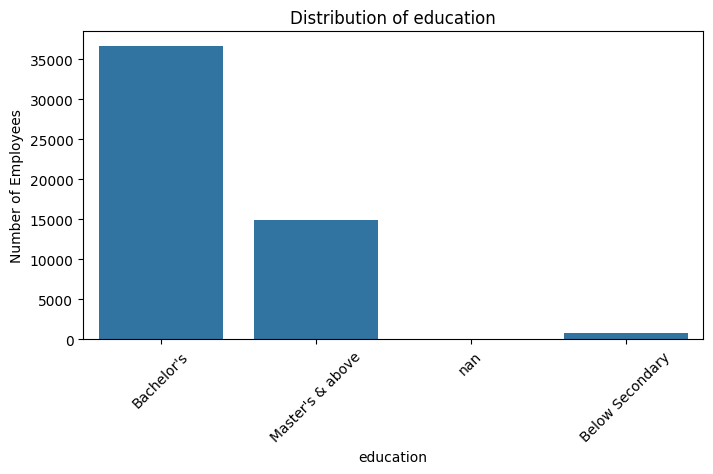

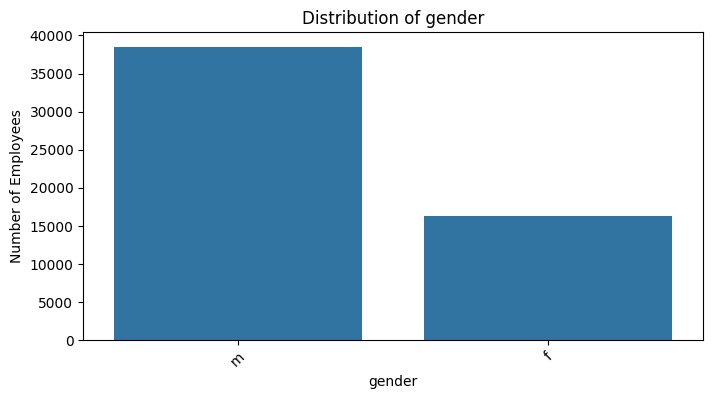

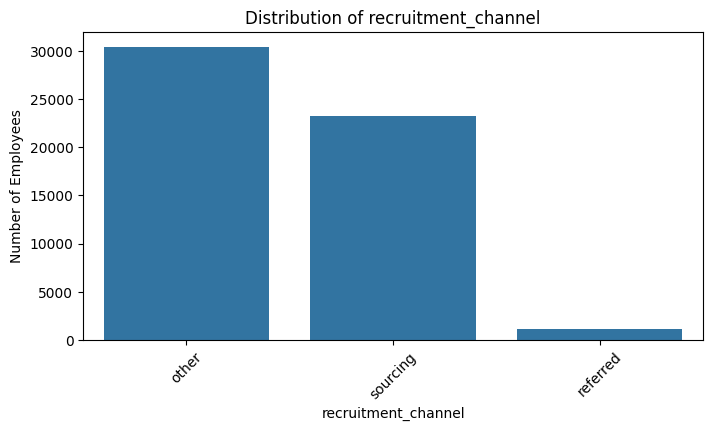

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=train,
        x=col,
        order=train[col].value_counts(dropna=False).index
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Number of Employees')
    plt.xticks(rotation=45)

    plt.show()

Numerical features vs promotion

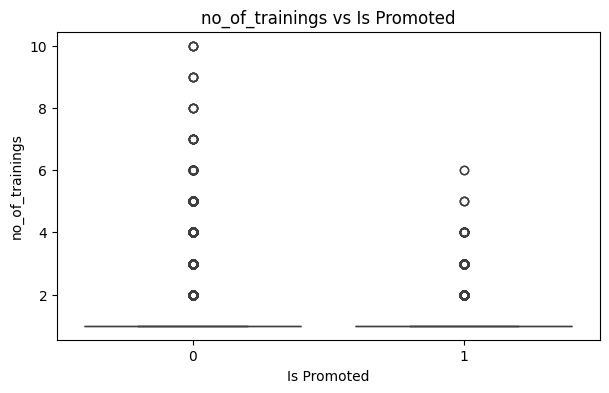

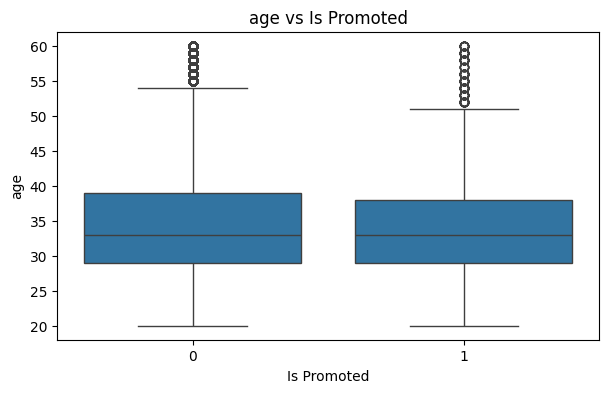

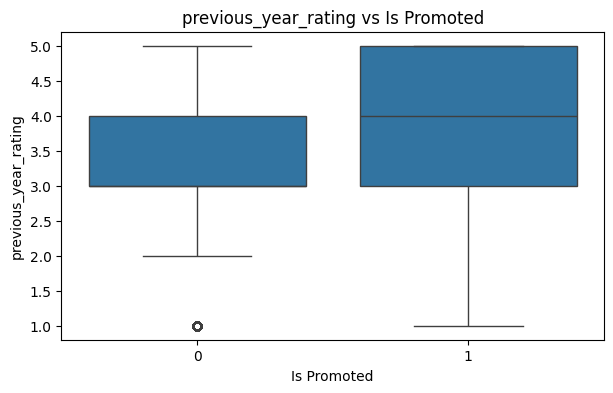

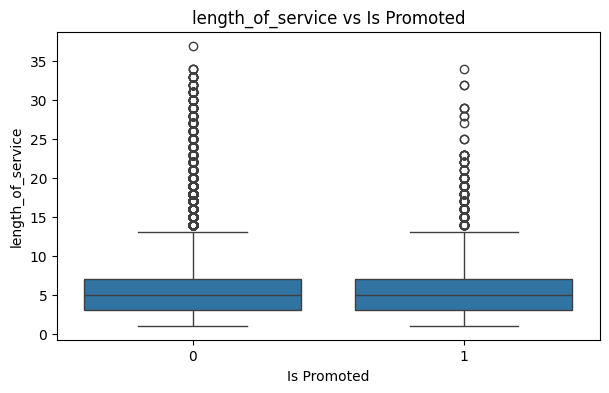

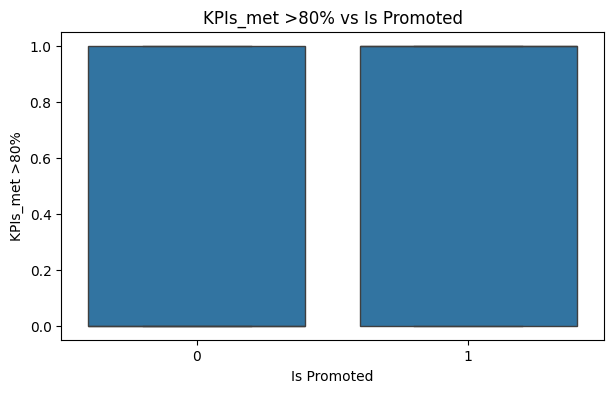

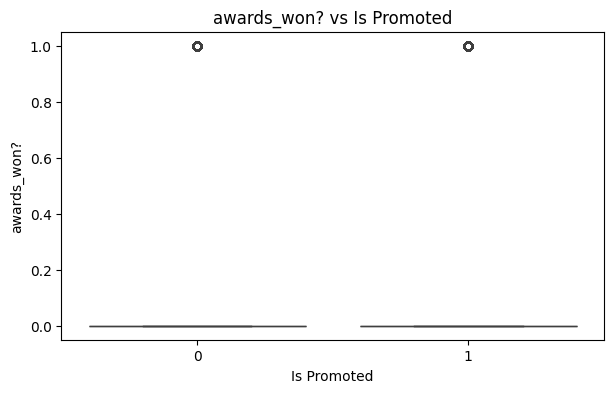

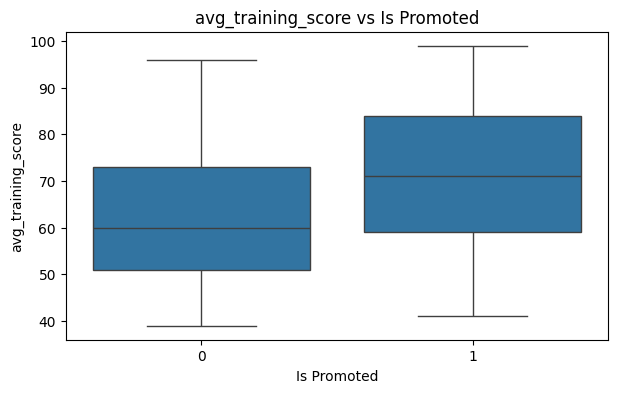

In [ ]:
for col in numeric_features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=train,
        x='is_promoted',
        y=col
    )

    plt.title(f'{col} vs Is Promoted')
    plt.xlabel('Is Promoted')
    plt.ylabel(col)

    plt.show()

Categorical features vs promotion

In [ ]:
for col in categorical_cols:

    print(f"\n===== {col} vs Is Promoted =====")

    result = pd.crosstab(
        train[col],
        train['is_promoted'],
        normalize='index'
    ) * 100

    print(result.round(2))


===== department vs Is Promoted =====
is_promoted            0      1
department                     
Analytics          90.43   9.57
Finance            91.88   8.12
HR                 94.38   5.62
Legal              94.90   5.10
Operations         90.99   9.01
Procurement        90.36   9.64
R&D                93.09   6.91
Sales & Marketing  92.80   7.20
Technology         89.24  10.76

===== region vs Is Promoted =====
is_promoted      0      1
region                   
region_1     90.49   9.51
region_10    92.13   7.87
region_11    94.37   5.63
region_12    93.40   6.60
region_13    91.31   8.69
region_14    92.50   7.50
region_15    92.09   7.91
region_16    93.04   6.96
region_17    86.31  13.69
region_18    96.77   3.23
region_19    93.94   6.06
region_2     91.99   8.01
region_20    94.24   5.76
region_21    95.62   4.38
region_22    88.58  11.42
region_23    88.34  11.66
region_24    96.46   3.54
region_25    87.42  12.58
region_26    93.67   6.33
region_27    92.10   7.90
re

Correlation Analysis

In [ ]:
correlation = train[numeric_features + ['is_promoted']].corr()

correlation

,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
no_of_trainings,1.000000,-0.081278,-0.063126,-0.057275,-0.045576,-0.007628,0.042517,-0.024896
age,-0.081278,1.000000,0.006008,0.657111,-0.025592,-0.008169,-0.048380,-0.017166
previous_year_rating,-0.063126,0.006008,1.000000,0.000253,0.351578,0.027738,0.075139,0.159320
length_of_service,-0.057275,0.657111,0.000253,1.000000,-0.077693,-0.039927,-0.038122,-0.010670
KPIs_met >80%,-0.045576,-0.025592,0.351578,-0.077693,1.000000,0.097000,0.078391,0.221582
awards_won?,-0.007628,-0.008169,0.027738,-0.039927,0.097000,1.000000,0.072138,0.195871
avg_training_score,0.042517,-0.048380,0.075139,-0.038122,0.078391,0.072138,1.000000,0.181147
is_promoted,-0.024896,-0.017166,0.159320,-0.010670,0.221582,0.195871,0.181147,1.000000


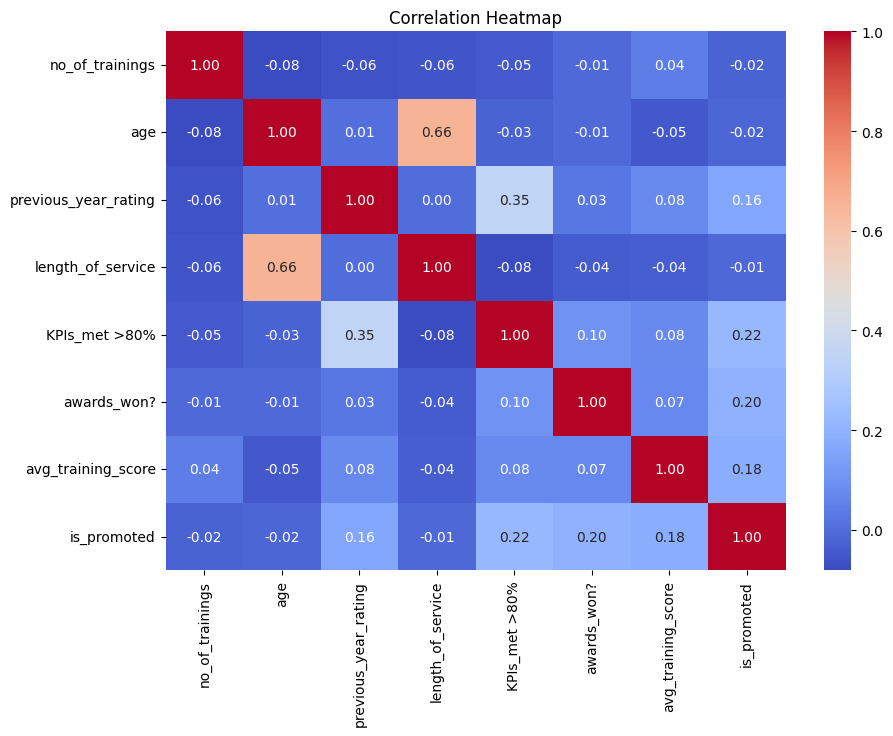

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

Compare Train and Test

In [ ]:
print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Train columns:
['employee_id', 'department', 'region', 'education', 'gender', 'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'KPIs_met >80%', 'awards_won?', 'avg_training_score', 'is_promoted']

Test columns:
['employee_id', 'department', 'region', 'education', 'gender', 'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'KPIs_met >80%', 'awards_won?', 'avg_training_score']


In [ ]:
print("Columns present in train but not test:")
print(set(train.columns) - set(test.columns))

print("\nColumns present in test but not train:")
print(set(test.columns) - set(train.columns))

Columns present in train but not test:
{'is_promoted'}

Columns present in test but not train:
set()


In [ ]:
comparison = pd.DataFrame({
    'Train dtype': train.drop(columns='is_promoted').dtypes,
    'Test dtype': test.dtypes
})

comparison

,Train dtype,Test dtype
employee_id,int64,int64
department,object,object
region,object,object
education,object,object
gender,object,object
recruitment_channel,object,object
no_of_trainings,int64,int64
age,int64,int64
previous_year_rating,float64,float64
length_of_service,int64,int64


In [ ]:
missing_comparison = pd.DataFrame({
    'Train Missing': train.drop(columns='is_promoted').isnull().sum(),
    'Test Missing': test.isnull().sum()
})

missing_comparison

,Train Missing,Test Missing
employee_id,0,0
department,0,0
region,0,0
education,2409,1034
gender,0,0
recruitment_channel,0,0
no_of_trainings,0,0
age,0,0
previous_year_rating,4124,1812
length_of_service,0,0


Train–Validation Split

In [ ]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=['is_promoted', 'employee_id'])
y = train['is_promoted']

test_ids = test['employee_id']
X_test = test.drop(columns=['employee_id'])

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (43846, 12)
X_val: (10962, 12)
y_train: (43846,)
y_val: (10962,)


In [ ]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True) * 100)

Training target distribution:
is_promoted
0    91.48383
1     8.51617
Name: proportion, dtype: float64

Validation target distribution:
is_promoted
0    91.479657
1     8.520343
Name: proportion, dtype: float64


Preprocessing

In [ ]:
print("Training missing values:")
print(X_train[['education', 'previous_year_rating']].isnull().sum())

print("\nValidation missing values:")
print(X_val[['education', 'previous_year_rating']].isnull().sum())

Training missing values:
education               1900
previous_year_rating    3298
dtype: int64

Validation missing values:
education               509
previous_year_rating    826
dtype: int64


In [ ]:
from sklearn.impute import SimpleImputer

education_imputer = SimpleImputer(strategy='most_frequent')

X_train['education'] = education_imputer.fit_transform(
    X_train[['education']]
).ravel()

X_val['education'] = education_imputer.transform(
    X_val[['education']]
).ravel()

In [ ]:
rating_imputer = SimpleImputer(strategy='median')

X_train['previous_year_rating'] = rating_imputer.fit_transform(
    X_train[['previous_year_rating']]
).ravel()

X_val['previous_year_rating'] = rating_imputer.transform(
    X_val[['previous_year_rating']]
).ravel()

In [ ]:
print("X_train missing values:")
print(X_train[['education', 'previous_year_rating']].isnull().sum())

print("\nX_val missing values:")
print(X_val[['education', 'previous_year_rating']].isnull().sum())

X_train missing values:
education               0
previous_year_rating    0
dtype: int64

X_val missing values:
education               0
previous_year_rating    0
dtype: int64


In [ ]:
outlier_cols = [
    'no_of_trainings',
    'age',
    'length_of_service',
    'avg_training_score'
]

for col in outlier_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((X_train[col] < lower_bound) |
                (X_train[col] > upper_bound)).sum()

    print(f"{col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")
    print(f"Outliers: {outliers}")
    print()

no_of_trainings
Q1: 1.0
Q3: 1.0
IQR: 0.0
Lower bound: 1.0
Upper bound: 1.0
Outliers: 8333

age
Q1: 29.0
Q3: 39.0
IQR: 10.0
Lower bound: 14.0
Upper bound: 54.0
Outliers: 1154

length_of_service
Q1: 3.0
Q3: 7.0
IQR: 4.0
Lower bound: -3.0
Upper bound: 13.0
Outliers: 2789

avg_training_score
Q1: 51.0
Q3: 76.0
IQR: 25.0
Lower bound: 13.5
Upper bound: 113.5
Outliers: 0



In [ ]:
X_train['age'].min(), X_train['age'].max()

(20, 60)

In [ ]:
X_train['length_of_service'].min(), X_train['length_of_service'].max()

(1, 34)

In [ ]:
#encoding
categorical_features = [
    'department',
    'region',
    'education',
    'gender',
    'recruitment_channel'
]

for col in categorical_features:
    print(f"\n{col}")
    print(X_train[col].value_counts(dropna=False))


department
department
Sales & Marketing    13468
Operations            9127
Technology            5738
Procurement           5689
Analytics             4276
Finance               2013
HR                    1923
Legal                  840
R&D                    772
Name: count, dtype: int64

region
region
region_2     9886
region_22    5159
region_7     3807
region_15    2269
region_13    2149
region_26    1800
region_31    1548
region_4     1360
region_27    1340
region_16    1181
region_28    1044
region_11    1034
region_23     940
region_29     774
region_32     764
region_19     674
region_17     672
region_14     671
region_20     669
region_25     647
region_5      634
region_6      548
region_30     524
region_10     524
region_8      521
region_1      489
region_12     405
region_24     404
region_9      345
region_21     326
region_3      269
region_34     232
region_33     212
region_18      25
Name: count, dtype: int64

education
education
Bachelor's          31333
Master's

In [ ]:
gender_mapping = {
    'm': 0,
    'f': 1
}

X_train['gender'] = X_train['gender'].map(gender_mapping)
X_val['gender'] = X_val['gender'].map(gender_mapping)

In [ ]:
print(X_train['gender'].value_counts())
print(X_val['gender'].value_counts())

gender
0    30717
1    13129
Name: count, dtype: int64
gender
0    7779
1    3183
Name: count, dtype: int64


In [ ]:
categorical_features = [
    'department',
    'region',
    'education',
    'recruitment_channel'
]

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    drop='first',
    sparse_output=False
)
X_train_cat = encoder.fit_transform(
    X_train[categorical_features]
)

X_val_cat = encoder.transform(
    X_val[categorical_features]
)

In [ ]:
print("Training encoded shape:", X_train_cat.shape)
print("Validation encoded shape:", X_val_cat.shape)

Training encoded shape: (43846, 45)
Validation encoded shape: (10962, 45)


In [ ]:
#scailing
scaled_features = [
    'no_of_trainings',
    'age',
    'length_of_service',
    'avg_training_score'
]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[scaled_features])
X_val_scaled = scaler.transform(X_val[scaled_features])

combine all the processed features

In [ ]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=scaled_features,
    index=X_train.index
)

X_val_scaled_df = pd.DataFrame(
    X_val_scaled,
    columns=scaled_features,
    index=X_val.index
)

In [ ]:
encoded_columns = encoder.get_feature_names_out(categorical_features)

X_train_cat_df = pd.DataFrame(
    X_train_cat,
    columns=encoded_columns,
    index=X_train.index
)

X_val_cat_df = pd.DataFrame(
    X_val_cat,
    columns=encoded_columns,
    index=X_val.index
)

In [ ]:
X_train_final = pd.concat([
    X_train_scaled_df,
    X_train[['previous_year_rating', 'KPIs_met >80%', 'awards_won?', 'gender']],
    X_train_cat_df
], axis=1)

X_val_final = pd.concat([
    X_val_scaled_df,
    X_val[['previous_year_rating', 'KPIs_met >80%', 'awards_won?', 'gender']],
    X_val_cat_df
], axis=1)

In [ ]:
print("X_train_processed shape:", X_train_final.shape)
print("X_val_processed shape:", X_val_final.shape)

print("\nMissing values:")
print(X_train_final.isnull().sum().sum())
print(X_val_final.isnull().sum().sum())

X_train_processed shape: (43846, 53)
X_val_processed shape: (10962, 53)

Missing values:
0
0


In [ ]:
X_train_final.head()

,no_of_trainings,age,length_of_service,avg_training_score,previous_year_rating,KPIs_met >80%,awards_won?,gender,department_Finance,department_HR,...,region_region_4,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Master's & above,recruitment_channel_referred,recruitment_channel_sourcing
25890,-0.416740,2.501497,3.084589,-0.103181,3.0,0,0,1,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
24121,-0.416740,0.546194,0.971895,0.495568,5.0,1,0,1,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
483,-0.416740,0.155133,-0.436567,0.645255,3.0,1,0,1,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14389,-0.416740,0.676547,-0.906054,-0.926461,3.0,0,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
45182,1.238966,0.806901,-0.201823,1.393691,3.0,0,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


model

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_final, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_log = log_model.predict(X_val_final)

from sklearn.metrics import f1_score, classification_report

f1_log = f1_score(y_val, y_pred_log)

print("Logistic Regression F1 Score:", f1_log)
print("\nClassification Report:")
print(classification_report(y_val, y_pred_log))

Logistic Regression F1 Score: 0.373022481265612

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     10028
           1       0.84      0.24      0.37       934

    accuracy                           0.93     10962
   macro avg       0.89      0.62      0.67     10962
weighted avg       0.93      0.93      0.91     10962



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_final, y_train)

y_pred_dt = dt_model.predict(X_val_final)

f1_dt = f1_score(y_val, y_pred_dt)

print("Decision Tree F1 Score:", f1_dt)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_dt))

Decision Tree F1 Score: 0.42163801820020225

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94     10028
           1       0.40      0.45      0.42       934

    accuracy                           0.90     10962
   macro avg       0.67      0.69      0.68     10962
weighted avg       0.90      0.90      0.90     10962



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_final, y_train)

y_pred_rf = rf_model.predict(X_val_final)

f1_rf = f1_score(y_val, y_pred_rf)

print("Random Forest F1 Score:", f1_rf)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf))

Random Forest F1 Score: 0.42857142857142855

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     10028
           1       0.83      0.29      0.43       934

    accuracy                           0.93     10962
   macro avg       0.88      0.64      0.70     10962
weighted avg       0.93      0.93      0.92     10962



In [ ]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_balanced.fit(X_train_final, y_train)

y_pred_rf_balanced = rf_balanced.predict(X_val_final)

f1_rf_balanced = f1_score(y_val, y_pred_rf_balanced)

print("Balanced Random Forest F1 Score:", f1_rf_balanced)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf_balanced))

Balanced Random Forest F1 Score: 0.44427001569858715

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     10028
           1       0.83      0.30      0.44       934

    accuracy                           0.94     10962
   macro avg       0.89      0.65      0.70     10962
weighted avg       0.93      0.94      0.92     10962



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train_final, y_train)

y_pred_gb = gb_model.predict(X_val_final)

f1_gb = f1_score(y_val, y_pred_gb)

print("Gradient Boosting F1 Score:", f1_gb)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_gb))

Gradient Boosting F1 Score: 0.4137353433835846

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10028
           1       0.95      0.26      0.41       934

    accuracy                           0.94     10962
   macro avg       0.94      0.63      0.69     10962
weighted avg       0.94      0.94      0.92     10962



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_tuned_1 = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_tuned_1.fit(X_train_final, y_train)

y_pred_rf_tuned_1 = rf_tuned_1.predict(X_val_final)

f1_rf_tuned_1 = f1_score(y_val, y_pred_rf_tuned_1)

print("Tuned Random Forest F1 Score:", f1_rf_tuned_1)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf_tuned_1))


Tuned Random Forest F1 Score: 0.36751269035532996

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.77      0.86     10028
           1       0.24      0.78      0.37       934

    accuracy                           0.77     10962
   macro avg       0.61      0.77      0.61     10962
weighted avg       0.91      0.77      0.82     10962



In [ ]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_balanced.fit(X_train_final, y_train)

y_pred_rf_balanced = rf_balanced.predict(X_val_final)

f1_rf_balanced = f1_score(y_val, y_pred_rf_balanced)

print("Balanced Random Forest F1 Score:", f1_rf_balanced)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf_balanced))

Balanced Random Forest F1 Score: 0.44427001569858715

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     10028
           1       0.83      0.30      0.44       934

    accuracy                           0.94     10962
   macro avg       0.89      0.65      0.70     10962
weighted avg       0.93      0.94      0.92     10962



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train_final, y_train)

y_pred_gb = gb_model.predict(X_val_final)

f1_gb = f1_score(y_val, y_pred_gb)

print("Gradient Boosting F1 Score:", f1_gb)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_gb))

Gradient Boosting F1 Score: 0.4137353433835846

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10028
           1       0.95      0.26      0.41       934

    accuracy                           0.94     10962
   macro avg       0.94      0.63      0.69     10962
weighted avg       0.94      0.94      0.92     10962



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_tuned_1 = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_tuned_1.fit(X_train_final, y_train)

y_pred_rf_tuned_1 = rf_tuned_1.predict(X_val_final)

f1_rf_tuned_1 = f1_score(y_val, y_pred_rf_tuned_1)

print("Tuned Random Forest F1 Score:", f1_rf_tuned_1)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf_tuned_1))

Tuned Random Forest F1 Score: 0.36751269035532996

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.77      0.86     10028
           1       0.24      0.78      0.37       934

    accuracy                           0.77     10962
   macro avg       0.61      0.77      0.61     10962
weighted avg       0.91      0.77      0.82     10962



In [ ]:
rf_tuned_2 = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_tuned_2.fit(X_train_final, y_train)

y_pred_rf_tuned_2 = rf_tuned_2.predict(X_val_final)

f1_rf_tuned_2 = f1_score(y_val, y_pred_rf_tuned_2)

print("Random Forest (200 trees) F1 Score:", f1_rf_tuned_2)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf_tuned_2))

Random Forest (200 trees) F1 Score: 0.4451460142067877

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     10028
           1       0.85      0.30      0.45       934

    accuracy                           0.94     10962
   macro avg       0.89      0.65      0.71     10962
weighted avg       0.93      0.94      0.92     10962



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=15,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_random.fit(X_train_final, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 15, 20, 25],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='f1', verbose=1)

In [ ]:
print("Best Parameters:")
print(rf_random.best_params_)

print("\nBest Cross-Validation F1:")
print(rf_random.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 25}

Best Cross-Validation F1:
0.43646692658587277


In [ ]:
best_rf = rf_random.best_estimator_

y_pred_best_rf = best_rf.predict(X_val_final)

from sklearn.metrics import f1_score, classification_report

f1_best_rf = f1_score(y_val, y_pred_best_rf)

print("Validation F1 Score:", f1_best_rf)
print("\nClassification Report:")
print(classification_report(y_val, y_pred_best_rf))

Validation F1 Score: 0.42278860569715143

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92     10028
           1       0.33      0.60      0.42       934

    accuracy                           0.86     10962
   macro avg       0.64      0.74      0.67     10962
weighted avg       0.91      0.86      0.88     10962



In [ ]:
final_model = rf_tuned_2

In [ ]:
X_test_processed = X_test.copy()

X_test_processed['education'] = education_imputer.transform(
    X_test_processed[['education']]
).ravel()

X_test_processed['previous_year_rating'] = rating_imputer.transform(
    X_test_processed[['previous_year_rating']]
).ravel()

In [ ]:
X_test_processed['gender'] = X_test_processed['gender'].map(gender_mapping)

In [ ]:
X_test_cat = encoder.transform(
    X_test_processed[categorical_features]
)

X_test_cat_df = pd.DataFrame(
    X_test_cat,
    columns=encoded_columns,
    index=X_test_processed.index
)

In [ ]:
X_test_scaled = scaler.transform(
    X_test_processed[scaled_features]
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=scaled_features,
    index=X_test_processed.index
)

In [ ]:
X_test_final = pd.concat([
    X_test_scaled_df,
    X_test_processed[
        ['previous_year_rating', 'KPIs_met >80%', 'awards_won?', 'gender']
    ],
    X_test_cat_df
], axis=1)

In [ ]:
print(X_test_final.shape)
print(X_train_final.shape)

(23490, 53)
(43846, 53)


In [ ]:
test_predictions = rf_tuned_2.predict(X_test_final)

In [ ]:
print(test_predictions.shape)
print(pd.Series(test_predictions).value_counts())

(23490,)
0    22830
1      660
Name: count, dtype: int64


In [ ]:
print(pd.Series(test_predictions).value_counts(normalize=True) * 100)

0    97.190294
1     2.809706
Name: proportion, dtype: float64


In [ ]:
val_predictions = rf_tuned_2.predict(X_val_final)

print("Validation predicted promotion rate:")
print(pd.Series(val_predictions).value_counts(normalize=True) * 100)

print("\nTest predicted promotion rate:")
print(pd.Series(test_predictions).value_counts(normalize=True) * 100)

Validation predicted promotion rate:
0    96.962233
1     3.037767
Name: proportion, dtype: float64

Test predicted promotion rate:
0    97.190294
1     2.809706
Name: proportion, dtype: float64


In [ ]:
print(sample_submission.head())
print(sample_submission.shape)
print(sample_submission.columns)

   employee_id  is_promoted
0         8724            0
1        74430            0
2        72255            0
3        38562            0
4        64486            0
(23490, 2)
Index(['employee_id', 'is_promoted'], dtype='object')


In [ ]:
sample_submission['is_promoted'] = test_predictions

In [ ]:
print(sample_submission.head())
print(sample_submission.shape)
print(sample_submission['is_promoted'].value_counts())

   employee_id  is_promoted
0         8724            0
1        74430            0
2        72255            0
3        38562            0
4        64486            0
(23490, 2)
is_promoted
0    22830
1      660
Name: count, dtype: int64


In [ ]:
sample_submission.to_csv('final_submission.csv', index=False)

In [ ]:
import os

print(os.path.exists('final_submission.csv'))

True


In [ ]:
final_submission = pd.read_csv('final_submission.csv')

print(final_submission.head())
print(final_submission.shape)
print(final_submission.columns)

   employee_id  is_promoted
0         8724            0
1        74430            0
2        72255            0
3        38562            0
4        64486            0
(23490, 2)
Index(['employee_id', 'is_promoted'], dtype='object')


In [ ]:
from google.colab import files

files.download('final_submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

exp 2:tuning the classification threshold

In [ ]:
y_val_prob = rf_tuned_2.predict_proba(X_val_final)[:, 1]

print(y_val_prob[:10])

[0.05  0.    0.    0.01  0.    0.335 0.145 0.025 0.17  0.   ]


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.10, 0.91, 0.01)

results = []

for threshold in thresholds:
    y_pred = (y_val_prob >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred)
    results.append((threshold, f1))

best_threshold, best_f1 = max(results, key=lambda x: x[1])

print("Best threshold:", best_threshold)
print("Best validation F1:", best_f1)

Best threshold: 0.29999999999999993
Best validation F1: 0.48766157461809634


In [ ]:
y_val_pred_05 = (y_val_prob >= 0.5).astype(int)

print("F1 at threshold 0.50:",
      f1_score(y_val, y_val_pred_05))

print("F1 at best threshold:",
      best_f1)

F1 at threshold 0.50: 0.4503518373729476
F1 at best threshold: 0.48766157461809634


In [ ]:
print("At threshold 0.50:")
print(pd.Series(y_val_pred_05).value_counts())

y_val_pred_best = (y_val_prob >= best_threshold).astype(int)

print("\nAt best threshold:")
print(pd.Series(y_val_pred_best).value_counts())

At threshold 0.50:
0    10617
1      345
Name: count, dtype: int64

At best threshold:
0    10194
1      768
Name: count, dtype: int64


In [ ]:
# Get probability of class 1 for the test data
test_prob = rf_tuned_2.predict_proba(X_test_final)[:, 1]

# Apply the best threshold found on validation data
test_predictions_tuned = (
    test_prob >= best_threshold
).astype(int)

# Check prediction counts
print(pd.Series(test_predictions_tuned).value_counts())

0    21868
1     1622
Name: count, dtype: int64


In [ ]:
submission_2 = sample_submission.copy()

submission_2['is_promoted'] = test_predictions_tuned

submission_2.to_csv(
    'final_submission_2.csv',
    index=False
)

print(submission_2.head())
print(submission_2.shape)

   employee_id  is_promoted
0         8724            0
1        74430            0
2        72255            0
3        38562            0
4        64486            0
(23490, 2)


In [ ]:
from google.colab import files

files.download('final_submission_2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

exp 3 XG boost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report

In [ ]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("Negative class:", neg)
print("Positive class:", pos)
print("Scale pos weight:", scale_pos_weight)

Negative class: 40112
Positive class: 3734
Scale pos weight: 10.742367434386717


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_final, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_val_final)

f1_xgb_05 = f1_score(y_val, y_pred_xgb)

print("XGBoost F1 at threshold 0.50:", f1_xgb_05)
print(classification_report(y_val, y_pred_xgb))

XGBoost F1 at threshold 0.50: 0.3908484270734032
              precision    recall  f1-score   support

           0       0.99      0.76      0.86     10028
           1       0.25      0.88      0.39       934

    accuracy                           0.77     10962
   macro avg       0.62      0.82      0.62     10962
weighted avg       0.92      0.77      0.82     10962



In [ ]:
y_val_prob_xgb = xgb_model.predict_proba(X_val_final)[:, 1]

In [ ]:
thresholds = np.arange(0.10, 0.91, 0.01)

xgb_results = []

for threshold in thresholds:
    y_pred = (y_val_prob_xgb >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred)
    xgb_results.append((threshold, f1))

best_threshold_xgb, best_f1_xgb = max(
    xgb_results,
    key=lambda x: x[1]
)

print("Best XGBoost threshold:", best_threshold_xgb)
print("Best XGBoost validation F1:", best_f1_xgb)

Best XGBoost threshold: 0.7999999999999996
Best XGBoost validation F1: 0.5252945252945252


In [ ]:
test_prob_xgb = xgb_model.predict_proba(X_test_final)[:, 1]

In [ ]:
test_predictions_xgb = (
    test_prob_xgb >= best_threshold_xgb
).astype(int)

In [ ]:
print(pd.Series(test_predictions_xgb).value_counts())

print(
    pd.Series(test_predictions_xgb)
    .value_counts(normalize=True) * 100
)

0    22490
1     1000
Name: count, dtype: int64
0    95.742869
1     4.257131
Name: proportion, dtype: float64


In [ ]:
submission_3 = sample_submission.copy()

submission_3['is_promoted'] = test_predictions_xgb

submission_3.to_csv(
    'final_submission_xgb.csv',
    index=False
)

print(submission_3.head())
print(submission_3.shape)

   employee_id  is_promoted
0         8724            0
1        74430            0
2        72255            0
3        38562            0
4        64486            0
(23490, 2)


In [ ]:
from google.colab import files

files.download('final_submission_xgb.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

experiment 4 :XG boost hyperparameter tuning


In [ ]:
xgb_model_2 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model_2.fit(X_train_final, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
y_val_prob_xgb_2 = xgb_model_2.predict_proba(X_val_final)[:, 1]

In [ ]:
thresholds = np.arange(0.10, 0.91, 0.01)

xgb_results_2 = []

for threshold in thresholds:
    y_pred = (y_val_prob_xgb_2 >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred)
    xgb_results_2.append((threshold, f1))

best_threshold_xgb_2, best_f1_xgb_2 = max(
    xgb_results_2,
    key=lambda x: x[1]
)

print("Best XGBoost 2 threshold:", best_threshold_xgb_2)
print("Best XGBoost 2 validation F1:", best_f1_xgb_2)

Best XGBoost 2 threshold: 0.23999999999999994
Best XGBoost 2 validation F1: 0.5362663495838288


In [ ]:
test_prob_xgb_2 = xgb_model_2.predict_proba(X_test_final)[:, 1]

test_predictions_xgb_2 = (
    test_prob_xgb_2 >= best_threshold_xgb_2
).astype(int)

print("Predicted class counts:")
print(pd.Series(test_predictions_xgb_2).value_counts())

Predicted class counts:
0    22003
1     1487
Name: count, dtype: int64


In [ ]:
submission_xgb_2 = sample_submission.copy()

submission_xgb_2['is_promoted'] = test_predictions_xgb_2

submission_xgb_2.to_csv(
    'final_submission_xgb_2.csv',
    index=False
)

print("Submission file created successfully.")
print(submission_xgb_2.head())

Submission file created successfully.
   employee_id  is_promoted
0         8724            0
1        74430            0
2        72255            0
3        38562            0
4        64486            0


In [ ]:
from google.colab import files

files.download('final_submission_xgb_2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exp 5:Threshold refinment around 0.24

In [ ]:
fine_thresholds = np.arange(0.20, 0.29, 0.005)

fine_results = []

for threshold in fine_thresholds:
    y_pred = (y_val_prob_xgb_2 >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred)
    fine_results.append((threshold, f1))

best_fine_threshold, best_fine_f1 = max(
    fine_results,
    key=lambda x: x[1]
)

print("Best fine threshold:", best_fine_threshold)
print("Best fine validation F1:", best_fine_f1)

Best fine threshold: 0.24500000000000005
Best fine validation F1: 0.5403764420157863


In [ ]:
best_threshold_fine = 0.245

test_predictions_xgb_fine = (
    test_prob_xgb_2 >= best_threshold_fine
).astype(int)

print("Predicted class counts:")
print(pd.Series(test_predictions_xgb_fine).value_counts())

Predicted class counts:
0    22062
1     1428
Name: count, dtype: int64


In [ ]:
submission_xgb_fine = sample_submission.copy()

submission_xgb_fine['is_promoted'] = test_predictions_xgb_fine

submission_xgb_fine.to_csv(
    'final_submission_xgb_fine.csv',
    index=False
)

print("Submission created successfully.")
print(submission_xgb_fine.head())

Submission created successfully.
   employee_id  is_promoted
0         8724            0
1        74430            0
2        72255            0
3        38562            0
4        64486            0


In [ ]:
from google.colab import files

files.download('final_submission_xgb_fine.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

train a tuned xgboost model to know wheather f1 score is improving

In [ ]:
from xgboost import XGBClassifier

xgb_tuned_1 = XGBClassifier(
    n_estimators=800,
    max_depth=4,
    learning_rate=0.03,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_tuned_1.fit(
    X_train_final,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=800, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
y_val_prob_tuned_1 = xgb_tuned_1.predict_proba(
    X_val_final
)[:, 1]

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.10, 0.91, 0.01)

results_tuned_1 = []

for threshold in thresholds:
    y_pred = (
        y_val_prob_tuned_1 >= threshold
    ).astype(int)

    f1 = f1_score(y_val, y_pred)

    results_tuned_1.append(
        (threshold, f1)
    )

best_threshold_tuned_1, best_f1_tuned_1 = max(
    results_tuned_1,
    key=lambda x: x[1]
)

print("Best threshold:", best_threshold_tuned_1)
print("Best validation F1:", best_f1_tuned_1)

Best threshold: 0.7799999999999997
Best validation F1: 0.524506683640993


The final model selected was XGBoost. It achieved a validation F1-score of 0.5363. After tuning the classification threshold, a threshold of 0.245 gave the highest validation F1-score of 0.5404. Therefore, XGBoost with a threshold of 0.245 was used to make the final test predictions.
